# 04 – Risk Forecasting and Monte Carlo Simulation

**Project:** AI-Powered Project Planning & Risk Forecasting Platform

This notebook implements **probabilistic schedule forecasting** using **Monte Carlo simulation**.

Traditional project plans rely on **single deterministic estimates**, which often underestimate risk.

Monte Carlo simulation allows us to:

- simulate thousands of possible project outcomes
- estimate **probability distributions of completion dates**
- generate **P50 and P80 forecasts**
- support **data-driven planning decisions**

Key outputs:

- simulated completion time distribution
- probability of schedule delay
- P50 / P80 forecast estimates

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Dataset

We begin by loading the historical project dataset used throughout the capstone.

This dataset contains the actual and planned project durations that are needed to estimate historical delay patterns.

These historical delay patterns form the basis of the Monte Carlo simulation in this notebook.

In [3]:
project_df = pd.read_csv("../data/project_portfolio_history.csv")

project_df.head()

,Project_ID,Portfolio_Segment,Region,Delivery_Model,Planning_Mode,Complexity_Score,Planned_Duration_Days,Actual_Duration_Days,Delay_Days,Delay_Flag,...,Critical_Path_Task_Count,Vendor_Count,Change_Order_Count,Resource_Buffer_Pct,Weather_Risk_Index,Procurement_Risk_Index,Stakeholder_Alignment_Score,Requirements_Volatility_Score,Forecast_Error_Days,Outcome_Risk_Level
0,P001,Public Sector,South,Design-Build,Spreadsheet,69,301,296,-5,On Time,...,12,11,4,8.3,5.0,35.1,68.1,31.7,3,Low
1,P002,Infrastructure,Central,Design-Build,Spreadsheet,63,266,267,1,Delayed,...,11,8,7,12.0,10.3,7.0,60.2,56.6,1,Low
2,P003,Commercial,North,Agile Hybrid,Spreadsheet,68,304,304,0,On Time,...,14,10,4,4.4,40.9,72.5,52.9,43.3,2,Medium
3,P004,Commercial,West,EPC,Spreadsheet,50,244,245,1,Delayed,...,10,9,2,11.2,22.4,52.3,57.7,35.6,1,Low
4,P005,Industrial,South,Design-Build,Manual,61,292,299,7,Delayed,...,10,5,7,2.4,35.2,25.8,53.5,44.2,11,Low


## Select Duration Data

To simulate project completion risk, we focus on three schedule-related variables:

- **Planned_Duration_Days**  
- **Actual_Duration_Days**  
- **Delay_Days**

These variables allow us to compare what was planned against what actually happened and to derive a historical delay distribution.

That delay distribution is the core input for probabilistic forecasting.

In [4]:
project_df[[
    "Planned_Duration_Days",
    "Actual_Duration_Days",
    "Delay_Days"
]].describe()

,Planned_Duration_Days,Actual_Duration_Days,Delay_Days
count,360.000000,360.000000,360.000000
mean,276.752778,284.613889,7.861111
std,38.755968,48.612656,17.248233
min,162.000000,149.000000,-30.000000
25%,253.000000,253.750000,-4.000000
50%,276.500000,282.000000,8.000000
75%,305.000000,318.250000,19.000000
max,371.000000,427.000000,64.000000


## Delay Distribution

Before running the simulation, we examine the distribution of historical delays.

This step is important because Monte Carlo simulation depends on the assumption that future uncertainty can be approximated using patterns from historical data.

By looking at the distribution of `Delay_Days`, we can better understand:

- whether delays are typically small or large
- whether the distribution is symmetric or skewed
- whether early completions also occur

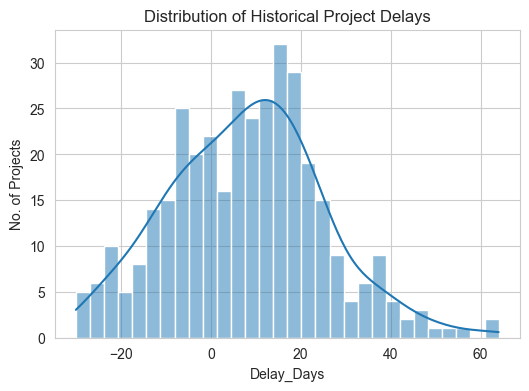

In [7]:
plt.figure(figsize=(6,4))

sns.histplot(
    project_df["Delay_Days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Historical Project Delays")
plt.xlabel("Delay_Days")
plt.ylabel("No. of Projects")

plt.show()

### Distribution of Historical Project Delays

- This chart visualizes the distribution of historical project delays using the `Delay_Days` variable.
- Each bar represents the **number of projects** whose delays fall within a specific range of days.
- **Negative values** indicate projects that finished **earlier than planned**, while **positive values** represent **delayed project completions**.
- Examining this distribution helps identify typical delay patterns in historical project data, including:
  - whether delays are generally **small or large**
  - whether the distribution is **symmetric or skewed**
  - whether **early completions** also occur
- These historical delay patterns serve as the **input distribution for the Monte Carlo simulation**.
- By sampling from this empirical distribution, the simulation generates **realistic scenarios of potential future project completion times under uncertainty**.

## Monte Carlo Simulation

Monte Carlo simulation is used to model uncertainty by generating many possible project outcomes.

Instead of assuming that a project will finish on a single fixed date, we simulate thousands of possible completion times based on historical variation.

### Simulation Logic

The simulation follows four steps:

1. Start with a planned project duration  
2. Randomly sample a delay from historical project data  
3. Add that delay to the planned duration  
4. Repeat this process many times  

The result is a **distribution of possible completion dates** rather than a single estimate.

This approach is more realistic because real project schedules are uncertain and can vary significantly depending on execution conditions.

In [8]:
planned_duration = 280
simulation_runs = 10000

historical_delays = project_df["Delay_Days"].values

In [9]:
simulated_completion_times = []

for i in range(simulation_runs):

    sampled_delay = np.random.choice(historical_delays)

    completion_time = planned_duration + sampled_delay

    simulated_completion_times.append(completion_time)

simulated_completion_times = np.array(simulated_completion_times)

## Simulated Completion Distribution

After running the simulation, we visualize the distribution of possible completion times.

This chart shows the range of outcomes that may occur if a project with the selected planned duration is subject to the same kind of uncertainty observed in historical projects.

The distribution helps answer an important planning question:

**How much variability should decision-makers expect in project completion time?**

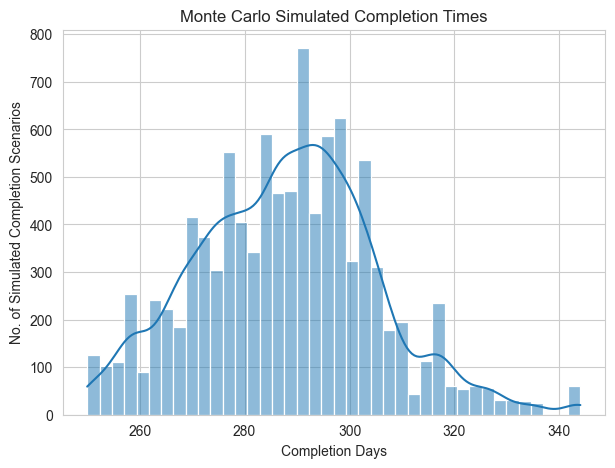

In [11]:
plt.figure(figsize=(7,5))

sns.histplot(
    simulated_completion_times,
    bins=40,
    kde=True
)

plt.title("Monte Carlo Simulated Completion Times")

plt.xlabel("Completion Days")
plt.ylabel("No. of Simulated Completion Scenarios")

plt.show()

### Simulated Completion Time Distribution

- This chart visualizes the distribution of **simulated project completion times** generated using a Monte Carlo simulation.
- Each bar represents the **number of simulated completion scenarios** that fall within a specific range of completion days.
- The simulation combines the **planned project duration** with **historical delay patterns** to model potential future outcomes.
- Examining this distribution helps decision-makers understand the **range and likelihood of possible completion times**, rather than relying on a single deterministic estimate.
- The chart highlights the **uncertainty and variability** that may occur in project delivery due to real-world factors observed in historical data.
- From this simulated distribution, key planning metrics such as **P50 (most likely completion)** and **P80 (risk-adjusted completion estimate)** can be derived.
- These probabilistic forecasts support **more realistic project planning and risk management**, allowing stakeholders to account for uncertainty when estimating project timelines.

## Calculate Forecast Percentiles

To make the simulation results useful for decision-making, we calculate forecast percentiles.

Two standard project forecasting metrics are:

- **P50:** 50% probability the project will finish before this date

- **P80:** 80% probability the project will finish before this date

These metrics are widely used because they translate uncertainty into practical planning targets.

Organizations often use **P80 commitments** for realistic planning.

In [12]:
p50 = np.percentile(simulated_completion_times, 50)
p80 = np.percentile(simulated_completion_times, 80)

print("P50 Forecast:", round(p50,1))
print("P80 Forecast:", round(p80,1))

P50 Forecast: 288.0
P80 Forecast: 302.0


### Forecast Percentiles (P50 and P80)

- To make the Monte Carlo simulation results actionable for project planning, we calculate **forecast percentiles** from the simulated completion times.
- Percentiles summarize the distribution of simulated outcomes and provide **probability-based completion estimates**.
- Two commonly used forecasting metrics are:
  - **P50 (50th percentile)**  
    - Indicates the completion time where **50% of simulated scenarios finish earlier** and **50% finish later**.  
    - Often interpreted as the **most likely completion estimate**.
  - **P80 (80th percentile)**  
    - Indicates the completion time where **80% of simulated scenarios finish earlier**.  
    - Commonly used as a **risk-adjusted planning estimate**.
- In this simulation:
  - **P50 Forecast: 288 days** → Half of the simulated projects finish before 288 days.
  - **P80 Forecast: 302 days** → 80% of simulated projects finish before 302 days.
- These percentile forecasts help translate simulation uncertainty into **practical planning targets**, enabling decision-makers to choose completion commitments based on their desired **risk tolerance**.

## Visualize Forecast Percentiles

We now overlay the P50 and P80 values on the simulated completion distribution.

This makes it easier to interpret the forecast and communicate schedule uncertainty visually.

From a stakeholder perspective, this is especially useful because it converts simulation output into clear planning references:

- a median forecast
- a risk-adjusted commitment forecast

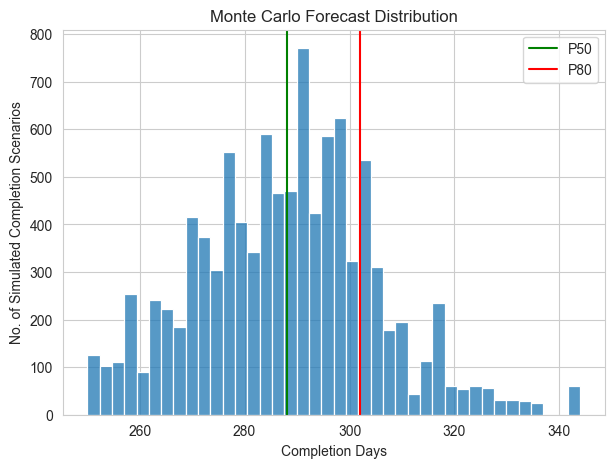

In [14]:
plt.figure(figsize=(7,5))

sns.histplot(
    simulated_completion_times,
    bins=40
)

plt.axvline(p50, color="green", label="P50")
plt.axvline(p80, color="red", label="P80")

plt.title("Monte Carlo Forecast Distribution")
plt.xlabel("Completion Days")
plt.ylabel("No. of Simulated Completion Scenarios")

plt.legend()

plt.show()

### Monte Carlo Forecast Distribution

- This chart visualizes the **distribution of simulated project completion times** generated through the Monte Carlo simulation.
- Each bar represents the **number of simulated completion scenarios** that fall within a specific range of completion days.
- The simulation repeatedly samples from the **historical delay distribution** and adds these delays to the planned project duration to estimate possible completion outcomes.
- The **green vertical line (P50)** represents the completion time where **50% of simulated scenarios finish earlier**.  
  - This is often interpreted as the **most likely completion estimate**.
- The **red vertical line (P80)** represents the completion time where **80% of simulated scenarios finish earlier**.  
  - This value is commonly used as a **risk-adjusted planning target**.
- The distance between the P50 and P80 values highlights the **uncertainty and variability** in project completion times.
- This probabilistic view allows decision-makers to move beyond a single estimate and instead plan using **confidence-based completion forecasts**.

## Probability of Delay

In addition to percentile forecasts, we also estimate the probability that the project will exceed its original planned duration.

This is a direct measure of schedule risk.

For project managers and stakeholders, this metric is valuable because it answers a practical question:

**What is the likelihood that the project will finish late?**

In [15]:
prob_delay = (simulated_completion_times > planned_duration).mean()

print("Probability of delay:", round(prob_delay*100,2), "%")

Probability of delay: 66.17 %


### Probability of Project Delay

- This calculation estimates the **probability that the project will finish later than the planned duration**
- The probability is derived from the **Monte Carlo simulation results**, which contain thousands of simulated project completion times.
- For each simulated outcome, the completion time is compared to the **planned project duration**.
- If the simulated completion time is **greater than the planned duration**, that scenario is counted as a **delay**.
- The proportion of delayed scenarios relative to the total number of simulations represents the **estimated probability of project delay**.
- In this simulation, the probability of delay is **66.17%**, meaning that approximately **two-thirds of simulated project scenarios finish later than the planned schedule**.
- This metric provides a **risk indicator for project managers**, helping them assess whether the planned schedule is realistic or whether additional buffers or mitigation strategies may be required.

## Planning Insights

Monte Carlo forecasting provides several important planning insights:

• Projects often contain **significant schedule uncertainty** and should not be treated as fixed commitments.

• Deterministic planning tends to underestimate delivery risk.

• P50 and P80 forecasts provide **more realistic commitment dates** than a single target date.

• Simulation enables project managers to communicate **probability-based forecasts to stakeholders**.

These forecasting capabilities are integrated into the **AI-powered planning platform**, allowing teams to generate risk-adjusted project schedules and make better decisions. Monte Carlo forecasting is a key capability of the platform because it allows teams to move from static schedules to **risk-aware planning decisions**.